# 4D Flow kt-Gaussian Undersampling Demo

This notebook follows the CMRx4DFlow undersampling demo style, but generates masks by importing the current `scripts/generate_4dflow_ktgaussian_train.py` implementation. It visualizes R10-R50 masks, then compares GT and undersampled k-space/image views for each acceleration.

In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

# Find repository root whether Jupyter starts in repo root or scripts/vis_tools.
cwd = Path.cwd().resolve()
repo_root = next(
    p for p in [cwd, *cwd.parents]
    if (p / "scripts" / "generate_4dflow_ktgaussian_train.py").exists()
)
sys.path.insert(0, str(repo_root / "scripts"))

from generate_4dflow_ktgaussian_train import (
    DEFAULT_ACCELERATIONS,
    generate_ktgaussian_mask_2d,
    stable_seed,
    to_broadcast_mask,
)

print("repo_root:", repo_root)

repo_root: /localhome/zhanghs/NV-Raw2insights-MRI


In [2]:
# ---- Edit this cell ----
patient_dir = Path("/SSDHome/share/haosen/4dflow/TrainSet/Aorta/Center007/GE_30T_Architect/P001")

accelerations = tuple(DEFAULT_ACCELERATIONS)  # (10, 20, 30, 40, 50)
base_seed = 2026  # same default as generate_4dflow_ktgaussian_train.py; set -1 for random

# Visualization indices.
v_idx = 0
t_idx = 0
c_idx = 0
spe_idx = None  # None -> SPE // 2

# Save PNG copies of every figure.
save_figs = True
out_dir = repo_root / "outputs" / "vis_4dflow_undersampling" / patient_dir.name
out_dir.mkdir(parents=True, exist_ok=True)
out_dir

PosixPath('/localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001')

In [3]:
def read_mat_dict(path: Path) -> dict:
    try:
        with h5py.File(path, "r", swmr=True) as f:
            return {key: f[key][()] for key in f.keys()}
    except Exception:
        return {key: val for key, val in scipy.io.loadmat(path).items() if not key.startswith("__")}


def first_array(path: Path, preferred_keys: tuple[str, ...]) -> np.ndarray:
    data = read_mat_dict(path)
    for key in preferred_keys:
        if key in data:
            print(f"{path.name}: key={key}, shape={np.asarray(data[key]).shape}")
            return np.asarray(data[key])
    for key, value in data.items():
        print(f"{path.name}: key={key}, shape={np.asarray(value).shape}")
        return np.asarray(value)
    raise ValueError(f"No array found in {path}")


def to_complex(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if np.iscomplexobj(arr):
        return arr
    if arr.dtype.fields is not None and "real" in arr.dtype.fields and "imag" in arr.dtype.fields:
        return arr["real"] + 1j * arr["imag"]
    if arr.ndim > 0 and arr.shape[-1] == 2 and np.issubdtype(arr.dtype, np.floating):
        return arr[..., 0] + 1j * arr[..., 1]
    return arr.astype(np.complex64)


def k2i_numpy(kspace: np.ndarray, ax=(-1, -2, -3)) -> np.ndarray:
    return np.fft.fftshift(
        np.fft.ifftn(np.fft.ifftshift(kspace, axes=ax), axes=ax, norm="ortho"),
        axes=ax,
    )


def robust_window(*arrays, percentiles=(1, 99.9)):
    pooled = np.concatenate([np.asarray(x).ravel() for x in arrays])
    vmin, vmax = np.percentile(pooled, percentiles)
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or vmin == vmax:
        vmin = float(np.nanmin(pooled))
        vmax = float(np.nanmax(pooled))
        if vmin == vmax:
            vmin, vmax = vmin - 1.0, vmax + 1.0
    return vmin, vmax


def coil_combine_volume(kdata_vt: np.ndarray, coilmap: np.ndarray) -> np.ndarray:
    # kdata_vt: (Nc, SPE, PE, FE), coilmap: (Nc, SPE, PE, FE)
    return np.sum(k2i_numpy(kdata_vt, ax=(-1, -2, -3)) * np.conj(coilmap), axis=0)


def maybe_save(fig, filename: str):
    if save_figs:
        path = out_dir / filename
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print("saved:", path)

In [4]:
kdata_full = to_complex(first_array(patient_dir / "kdata_full.mat", ("kdata_full", "kdata", "kspace_full", "kspace")))
coilmap = to_complex(first_array(patient_dir / "coilmap.mat", ("coilmap", "csm", "sensitivity_maps", "sens_maps")))

Nv, Nt, Nc, SPE, PE, FE = kdata_full.shape
assert coilmap.shape == (Nc, SPE, PE, FE), f"Expected coilmap {(Nc, SPE, PE, FE)}, got {coilmap.shape}"

if spe_idx is None:
    spe_idx = SPE // 2

print("kdata_full:", kdata_full.shape, kdata_full.dtype)
print("coilmap:", coilmap.shape, coilmap.dtype)
print("indices:", {"v_idx": v_idx, "t_idx": t_idx, "c_idx": c_idx, "spe_idx": spe_idx})

kdata_full.mat: key=kdata_full, shape=(4, 16, 10, 30, 112, 108)
coilmap.mat: key=coilmap, shape=(10, 30, 112, 108)
kdata_full: (4, 16, 10, 30, 112, 108) complex64
coilmap: (10, 30, 112, 108) complex64
indices: {'v_idx': 0, 't_idx': 0, 'c_idx': 0, 'spe_idx': 15}


In [5]:
# Generate masks exactly through generate_4dflow_ktgaussian_train.py functions.
generated_masks = {}

for acc in accelerations:
    seed = None if base_seed < 0 else stable_seed(base_seed, patient_dir, acc)
    rng = np.random.default_rng(seed)
    masks_spe_pe_t = generate_ktgaussian_mask_2d(SPE, PE, Nt, acc, rng)
    usmask = to_broadcast_mask(masks_spe_pe_t)
    generated_masks[acc] = usmask
    actual_usrate = 1.0 / np.mean(usmask)
    print(
        f"R{acc}: mask={usmask.shape}, points/frame={int(masks_spe_pe_t[:, :, 0].sum())}, "
        f"actual={actual_usrate:.2f}x, seed={seed}"
    )

R10: mask=(1, 16, 1, 30, 112, 1), points/frame=336, actual=10.00x, seed=3855221250
R20: mask=(1, 16, 1, 30, 112, 1), points/frame=168, actual=20.00x, seed=2399001653
R30: mask=(1, 16, 1, 30, 112, 1), points/frame=112, actual=30.00x, seed=1675410416
R40: mask=(1, 16, 1, 30, 112, 1), points/frame=84, actual=40.00x, seed=1854855386
R50: mask=(1, 16, 1, 30, 112, 1), points/frame=67, actual=50.15x, seed=2943356853


## Masks

Each acceleration is shown with the same layout as the reference demo: single-frame mask as `(PE, SPE)` and temporal variation for one fixed SPE line as `(PE, Nt)`.

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/mask_R10.png


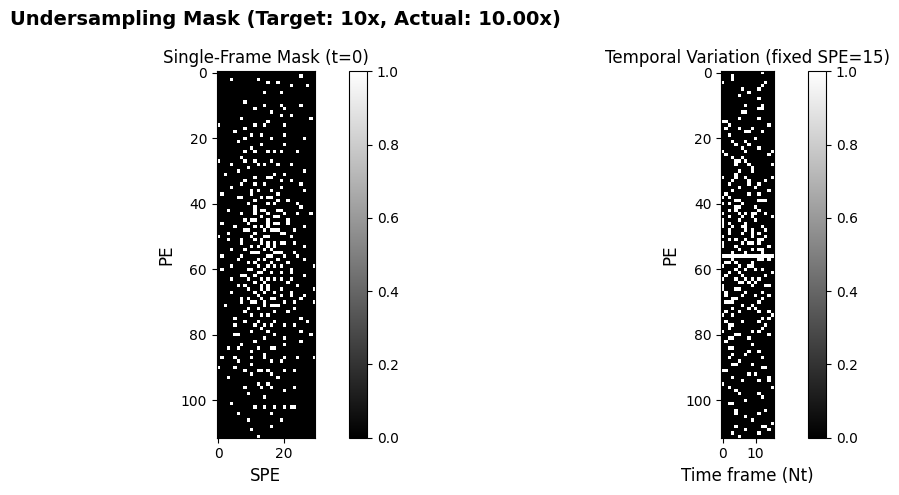

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/mask_R20.png


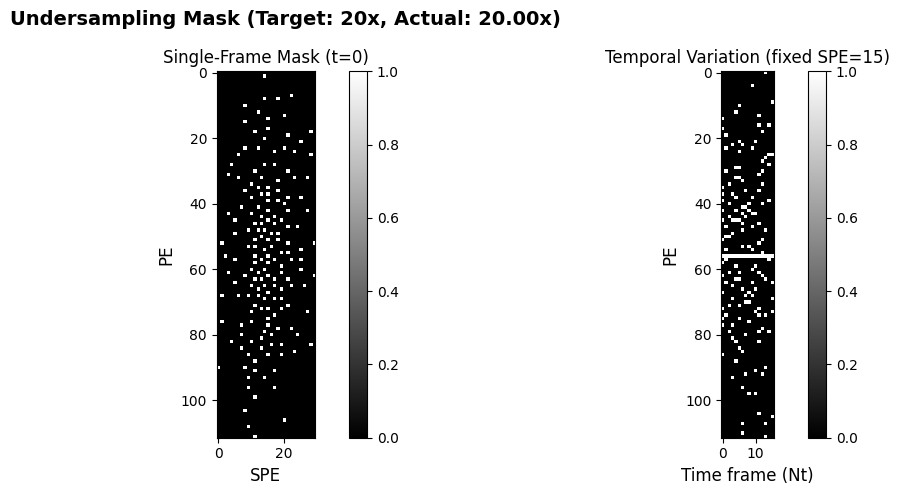

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/mask_R30.png


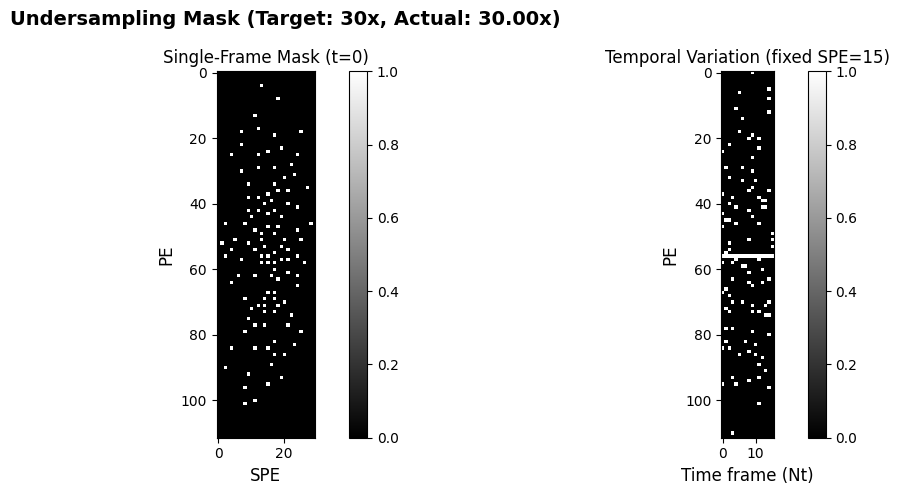

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/mask_R40.png


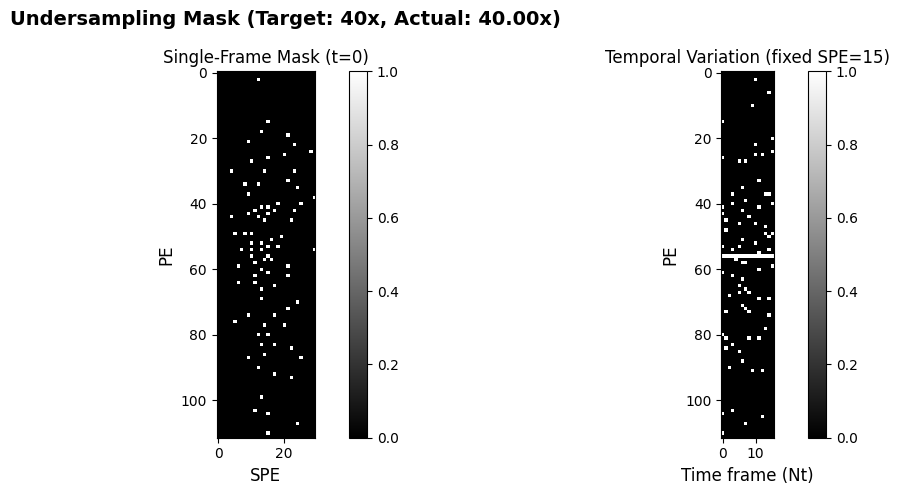

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/mask_R50.png


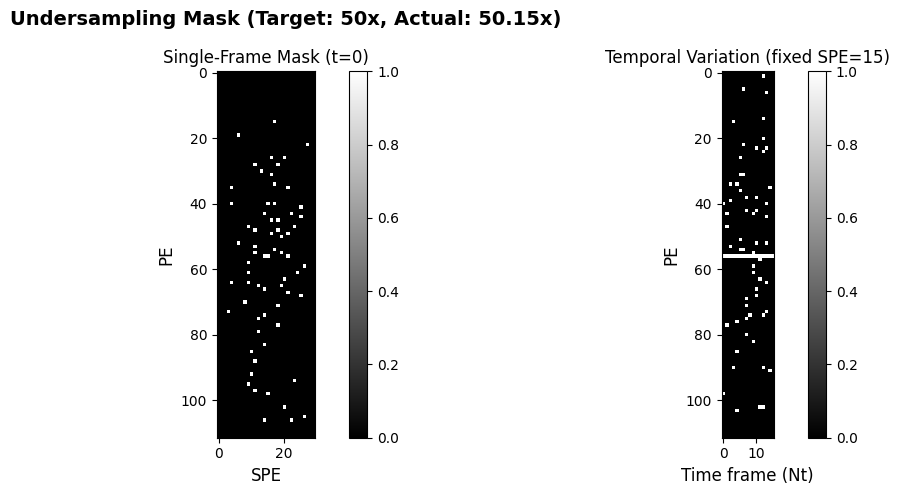

In [6]:
for acc, usmask in generated_masks.items():
    actual_usrate = 1.0 / np.mean(usmask)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        f"Undersampling Mask (Target: {acc}x, Actual: {actual_usrate:.2f}x)",
        fontsize=14,
        fontweight="bold",
    )

    im0 = axes[0].imshow(usmask[0, t_idx, 0, :, :, 0].T, cmap="gray")
    axes[0].set_ylabel("PE", fontsize=12)
    axes[0].set_xlabel("SPE", fontsize=12)
    axes[0].set_title(f"Single-Frame Mask (t={t_idx})", fontsize=12)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(usmask[0, :, 0, spe_idx, :, 0].T, cmap="gray")
    axes[1].set_ylabel("PE", fontsize=12)
    axes[1].set_xlabel("Time frame (Nt)", fontsize=12)
    axes[1].set_title(f"Temporal Variation (fixed SPE={spe_idx})", fontsize=12)
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    plt.tight_layout()
    maybe_save(fig, f"mask_R{acc}.png")
    plt.show()

## GT vs Undersampled

For memory efficiency, this visualization follows the selected `(v_idx, t_idx)` only. It applies `kdata_us = kdata_full * usmask` for that frame, then inverse FFTs and coil-combines with `coilmap`.

In [7]:
# Prepare GT panels for selected velocity encoding and time frame.
k_full_vt = kdata_full[v_idx, t_idx]  # (Nc, SPE, PE, FE)
img_full = coil_combine_volume(k_full_vt, coilmap)  # (SPE, PE, FE)

full_kspace_mag = np.abs(k_full_vt[c_idx, spe_idx, :, :])
full_img_mag = np.abs(img_full[spe_idx, :, :])

print("selected k-space:", k_full_vt.shape)
print("selected coil-combined image:", img_full.shape)

selected k-space: (10, 30, 112, 108)
selected coil-combined image: (30, 112, 108)


saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/gt_vs_us_R10.png


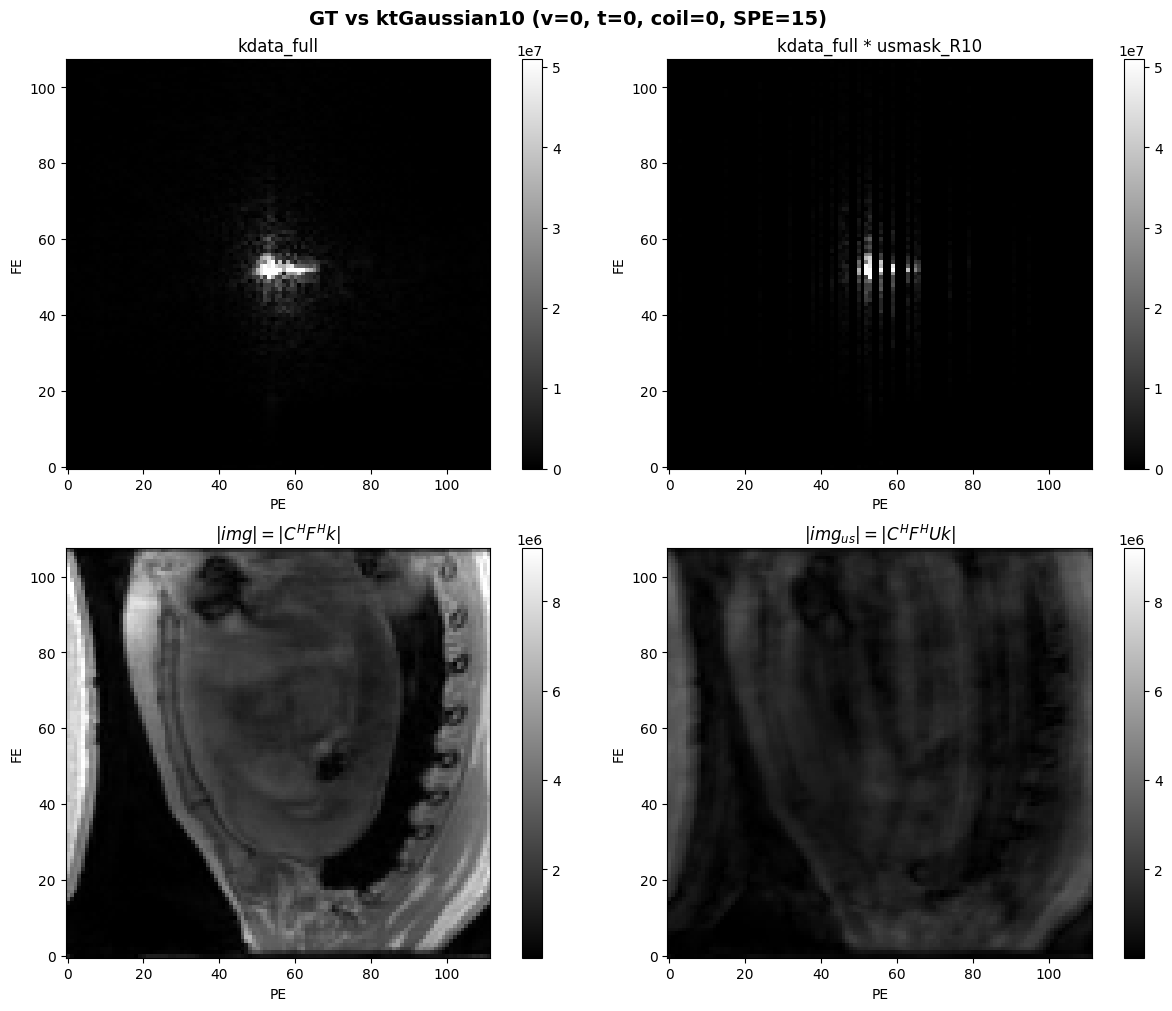

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/gt_vs_us_R20.png


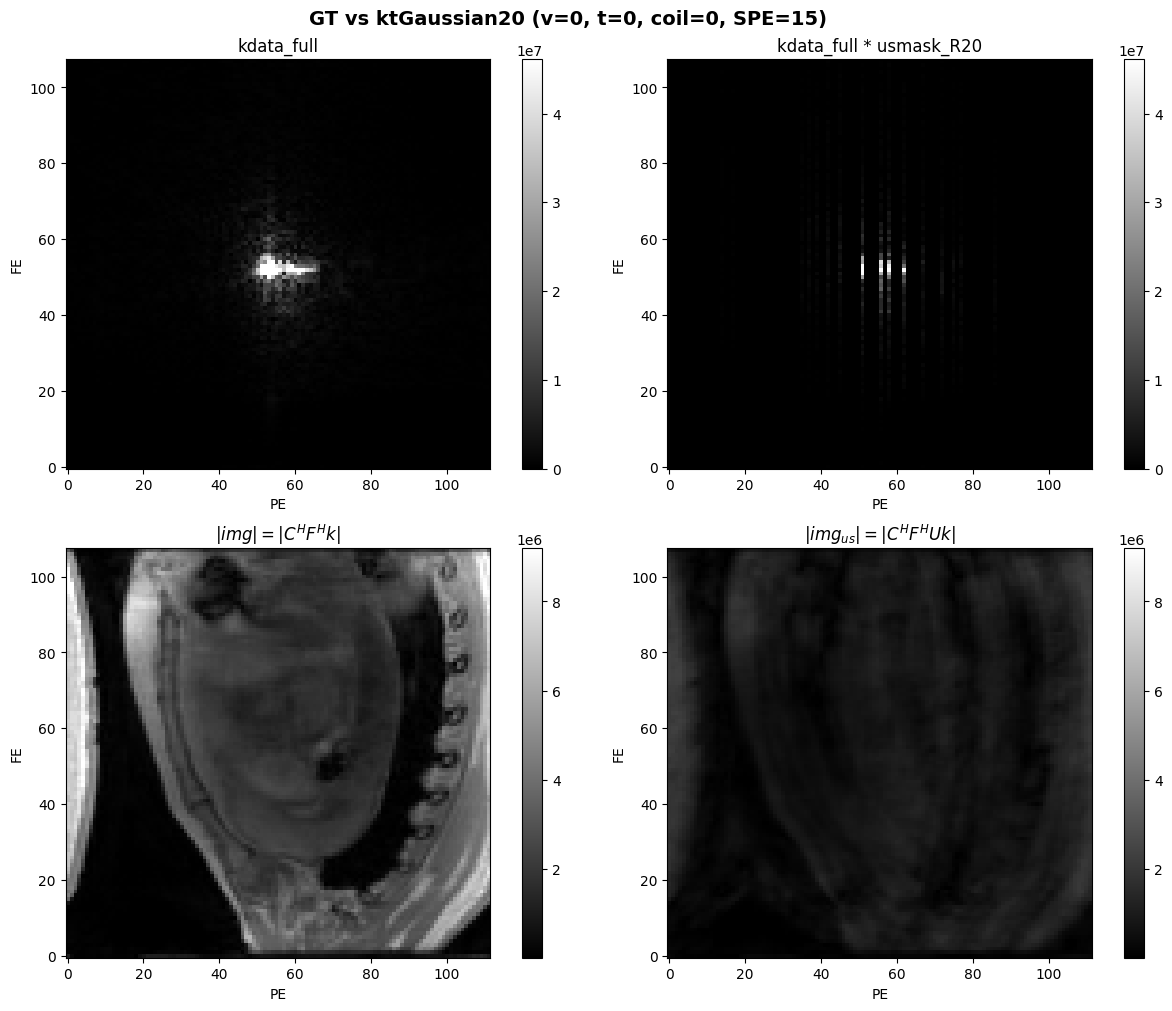

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/gt_vs_us_R30.png


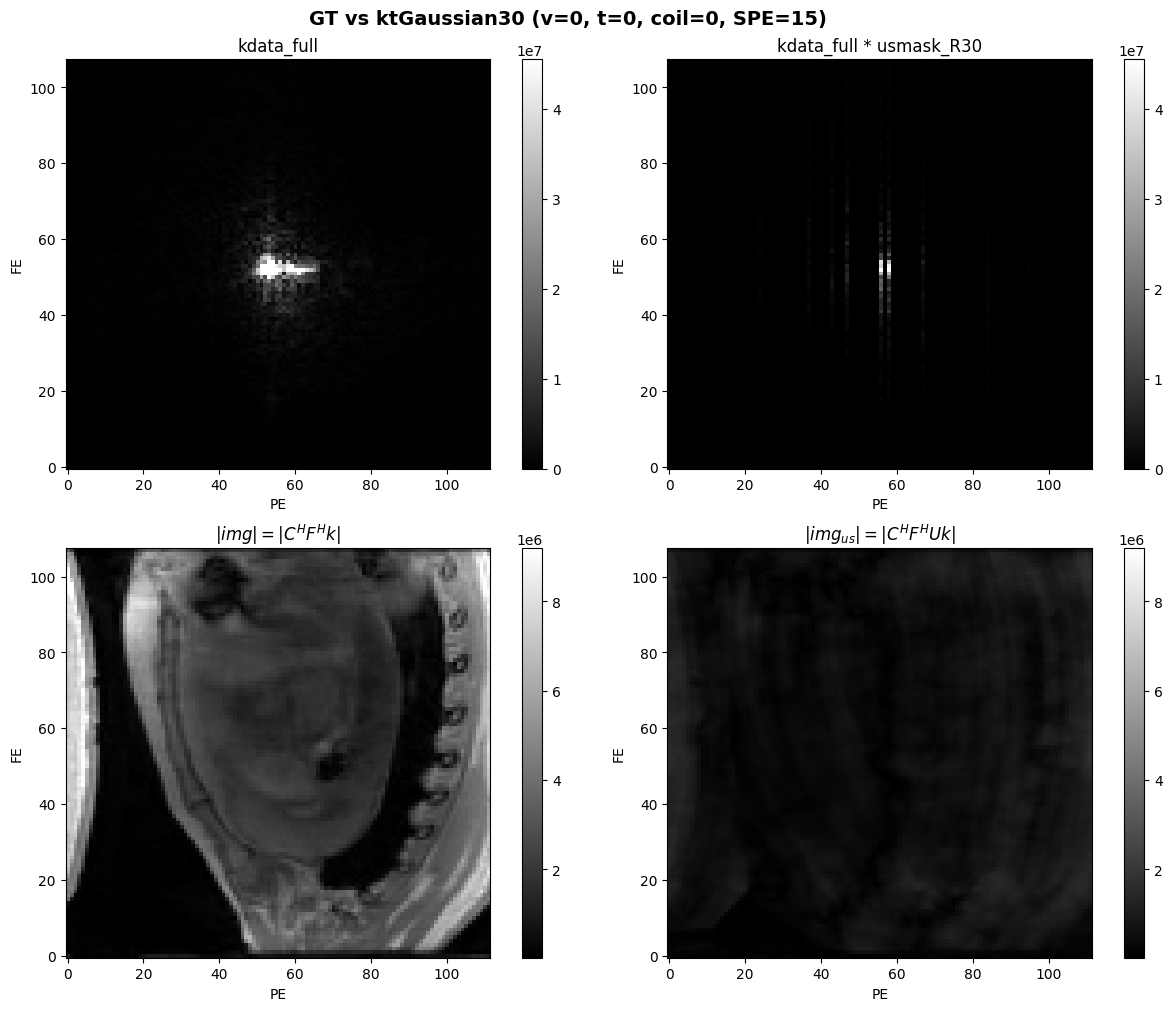

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/gt_vs_us_R40.png


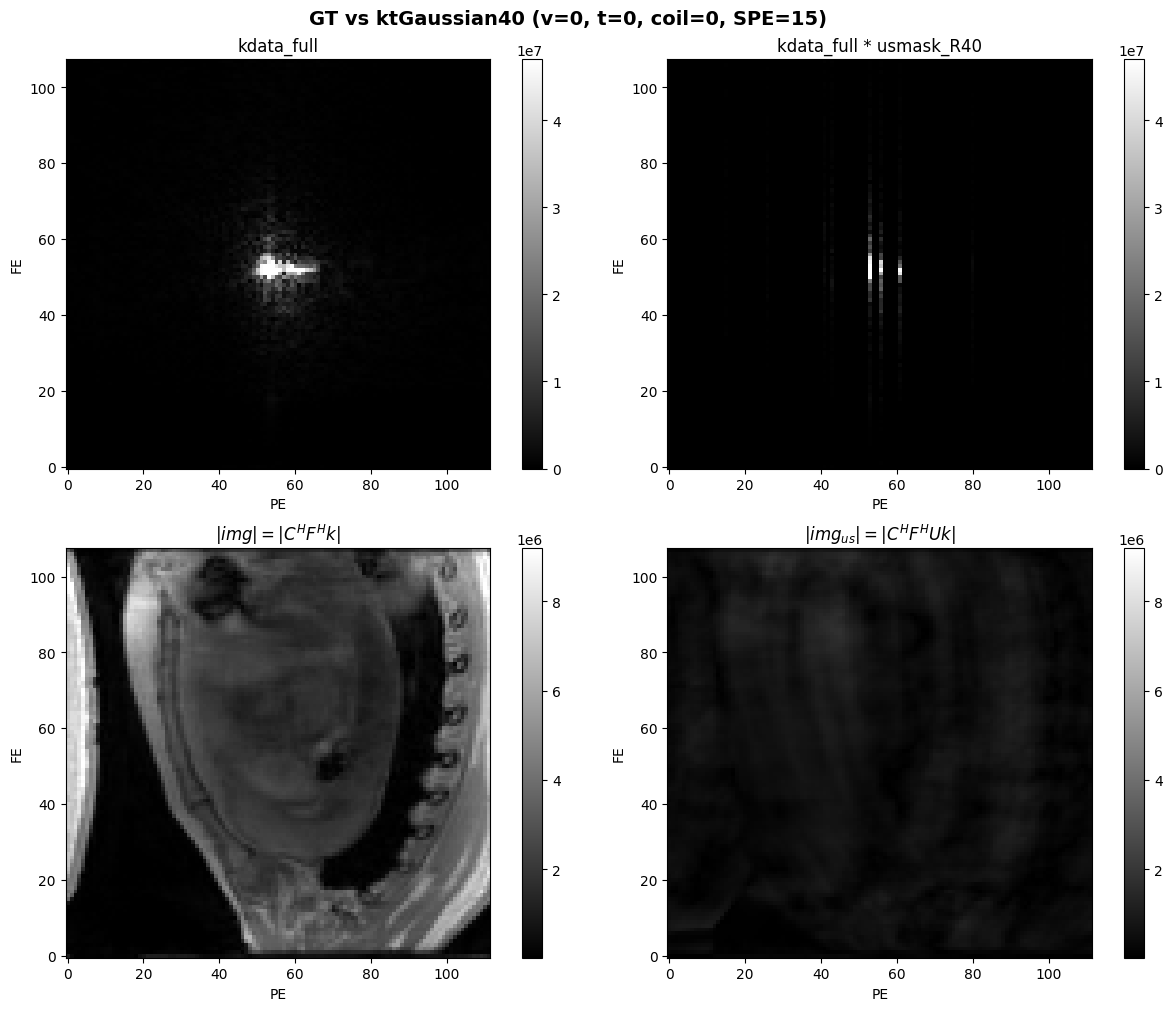

saved: /localhome/zhanghs/NV-Raw2insights-MRI/outputs/vis_4dflow_undersampling/P001/gt_vs_us_R50.png


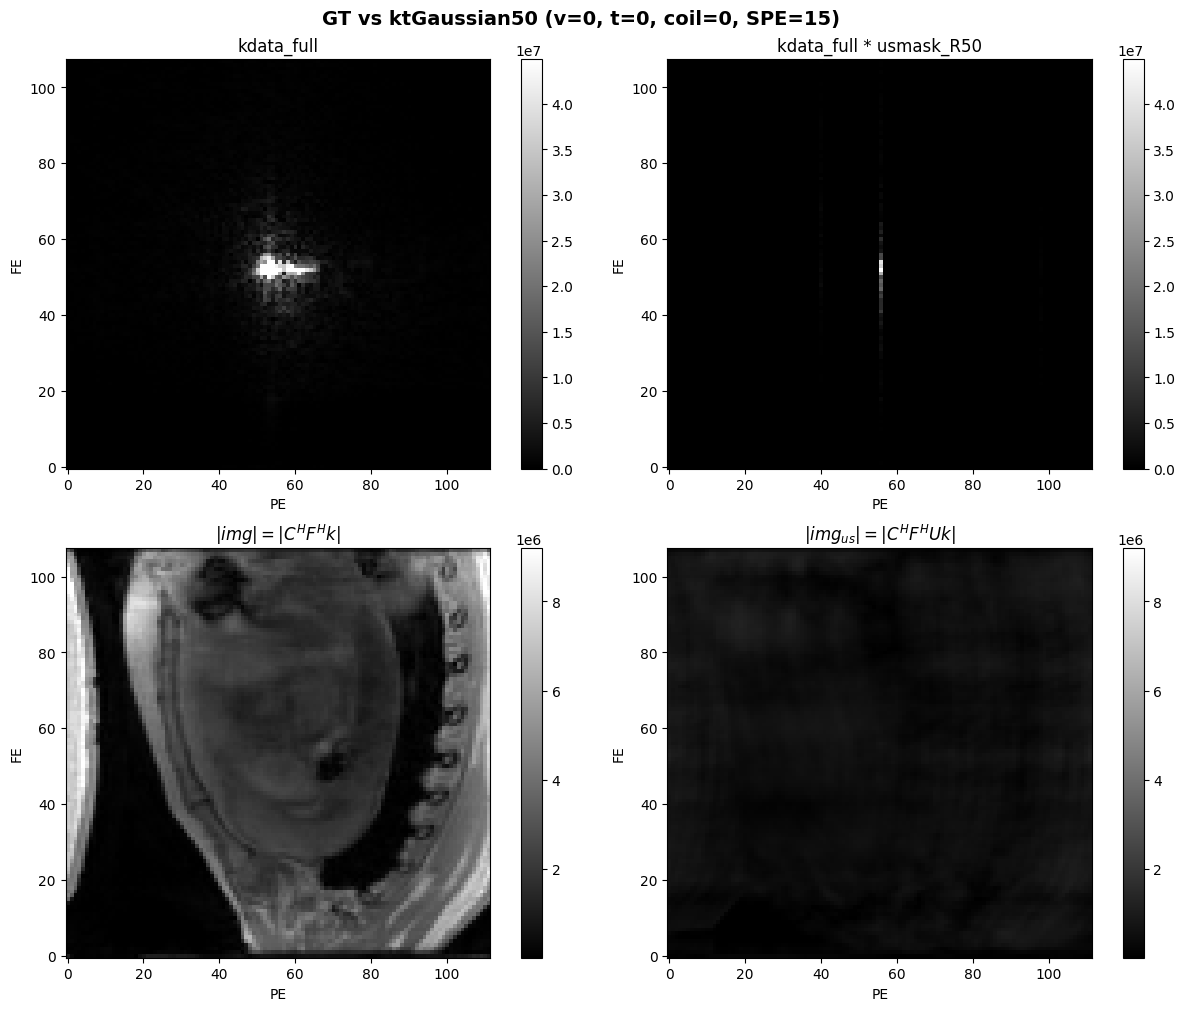

In [8]:
for acc, usmask in generated_masks.items():
    frame_mask = usmask[0, t_idx, 0, :, :, 0][None, :, :, None]  # (1, SPE, PE, 1), broadcast over coil and FE
    k_us_vt = k_full_vt * frame_mask
    img_us = coil_combine_volume(k_us_vt, coilmap)

    us_kspace_mag = np.abs(k_us_vt[c_idx, spe_idx, :, :])
    us_img_mag = np.abs(img_us[spe_idx, :, :])

    vmin_k, vmax_k = robust_window(full_kspace_mag, us_kspace_mag)
    vmin_i, vmax_i = robust_window(full_img_mag, us_img_mag)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    fig.suptitle(f"GT vs ktGaussian{acc} (v={v_idx}, t={t_idx}, coil={c_idx}, SPE={spe_idx})", fontsize=14, fontweight="bold")

    im00 = axes[0, 0].imshow(full_kspace_mag.T, cmap="gray", vmin=vmin_k, vmax=vmax_k, origin="lower")
    axes[0, 0].set_title("kdata_full", fontsize=12)
    axes[0, 0].set_xlabel("PE")
    axes[0, 0].set_ylabel("FE")
    fig.colorbar(im00, ax=axes[0, 0], fraction=0.046)

    im01 = axes[0, 1].imshow(us_kspace_mag.T, cmap="gray", vmin=vmin_k, vmax=vmax_k, origin="lower")
    axes[0, 1].set_title(f"kdata_full * usmask_R{acc}", fontsize=12)
    axes[0, 1].set_xlabel("PE")
    axes[0, 1].set_ylabel("FE")
    fig.colorbar(im01, ax=axes[0, 1], fraction=0.046)

    im10 = axes[1, 0].imshow(full_img_mag.T, cmap="gray", vmin=vmin_i, vmax=vmax_i, origin="lower")
    axes[1, 0].set_title(r"$|img| = |C^H F^H k|$", fontsize=12)
    axes[1, 0].set_xlabel("PE")
    axes[1, 0].set_ylabel("FE")
    fig.colorbar(im10, ax=axes[1, 0], fraction=0.046)

    im11 = axes[1, 1].imshow(us_img_mag.T, cmap="gray", vmin=vmin_i, vmax=vmax_i, origin="lower")
    axes[1, 1].set_title(r"$|img_{us}| = |C^H F^H U k|$", fontsize=12)
    axes[1, 1].set_xlabel("PE")
    axes[1, 1].set_ylabel("FE")
    fig.colorbar(im11, ax=axes[1, 1], fraction=0.046)

    maybe_save(fig, f"gt_vs_us_R{acc}.png")
    plt.show()